In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import time

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.77MB/s]


In [3]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

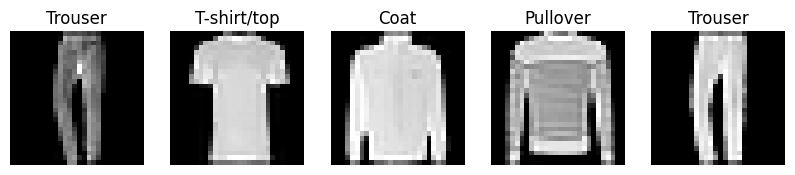

In [4]:
classes = train_dataset.classes

fig, axes = plt.subplots(1,5, figsize=(10,3))

for i in range(5):
    img, label = train_dataset[np.random.randint(len(train_dataset))]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(classes[label])
    axes[i].axis("off")

plt.show()

In [5]:
print("Train dataset size:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("Meaning: (Channels, Height, Width)")

Train dataset size: 60000
Image shape: torch.Size([1, 28, 28])
Meaning: (Channels, Height, Width)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, epochs=10):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    start = time.time()

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.view(images.size(0), -1).to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

    training_time = time.time() - start

    return train_losses, val_losses, training_time

In [7]:
def test_accuracy(model):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [8]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,32),
            nn.ReLU(),
            nn.Linear(32,10)
        )
    def forward(self,x):
        return self.net(x)

In [9]:
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.net(x)

In [10]:
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.net(x)

In [11]:
modelA = ModelA().to(device)
modelB = ModelB().to(device)
modelC = ModelC().to(device)

A_train,A_val,A_time = train_model(modelA)
B_train,B_val,B_time = train_model(modelB)
C_train,C_val,C_time = train_model(modelC)

A_acc = test_accuracy(modelA)
B_acc = test_accuracy(modelB)
C_acc = test_accuracy(modelC)

print("ModelA Accuracy:",A_acc)
print("ModelB Accuracy:",B_acc)
print("ModelC Accuracy:",C_acc)

ModelA Accuracy: 86.08
ModelB Accuracy: 87.47
ModelC Accuracy: 87.73


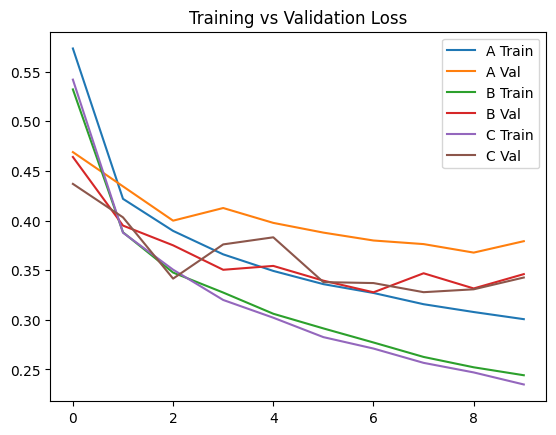

In [12]:
plt.plot(A_train,label="A Train")
plt.plot(A_val,label="A Val")

plt.plot(B_train,label="B Train")
plt.plot(B_val,label="B Val")

plt.plot(C_train,label="C Train")
plt.plot(C_val,label="C Val")

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [13]:
class SmallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,4),
            nn.ReLU(),
            nn.Linear(4,10)
        )
    def forward(self,x):
        return self.net(x)

In [14]:
class LargeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,1024),
            nn.ReLU(),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.net(x)

In [15]:
small = SmallModel().to(device)
large = LargeModel().to(device)

s_train,s_val,_ = train_model(small)
l_train,l_val,_ = train_model(large)

print("Small Model Accuracy:",test_accuracy(small))
print("Large Model Accuracy:",test_accuracy(large))

Small Model Accuracy: 80.39
Large Model Accuracy: 88.18


In [16]:
class BatchNormModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.net(x)

In [17]:
bn_model = BatchNormModel().to(device)

bn_train,bn_val,bn_time = train_model(bn_model)

print("BatchNorm Accuracy:",test_accuracy(bn_model))

BatchNorm Accuracy: 88.31


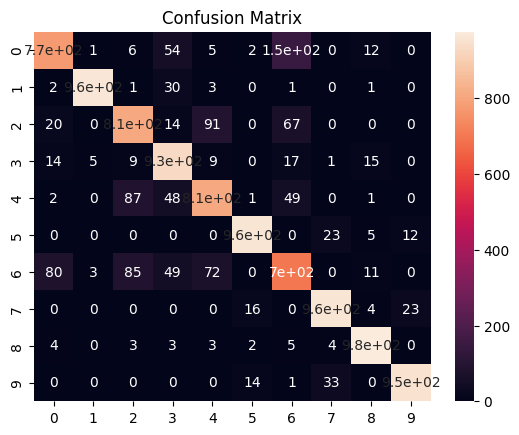

In [18]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images,labels in test_loader:

        images = images.view(images.size(0),-1).to(device)
        outputs = bn_model(images)

        _,pred = torch.max(outputs,1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels,all_preds)

sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")
plt.show()

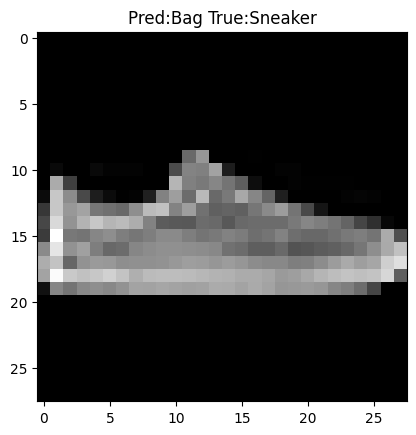

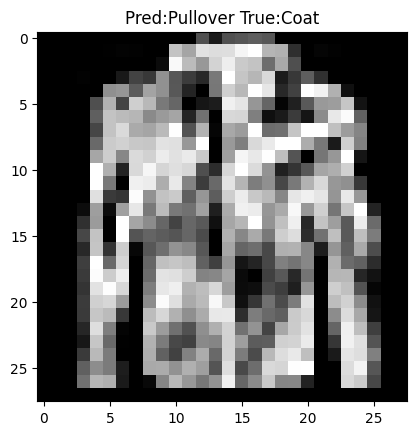

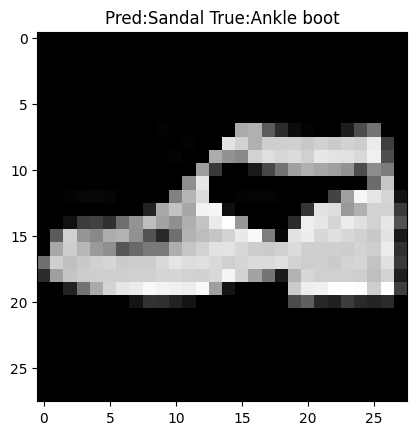

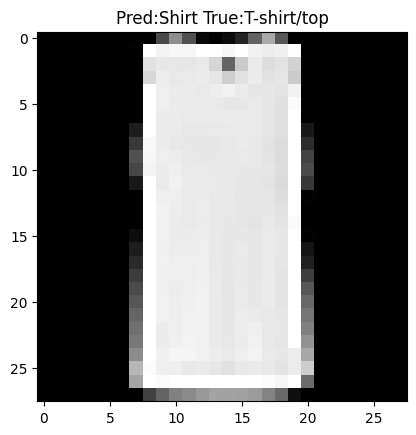

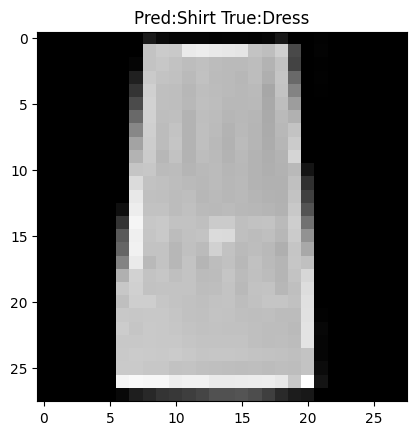

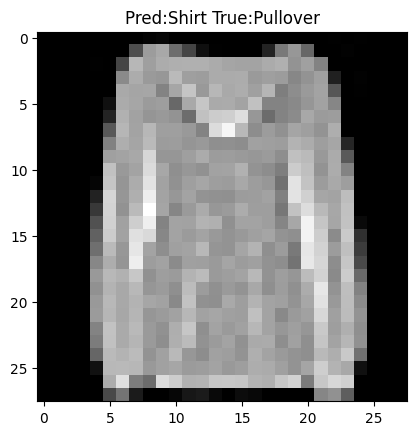

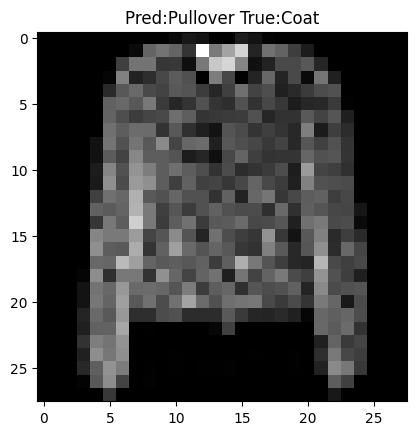

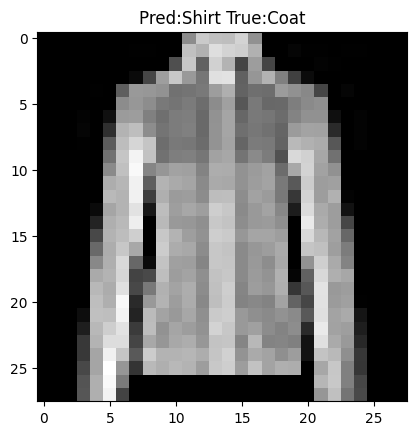

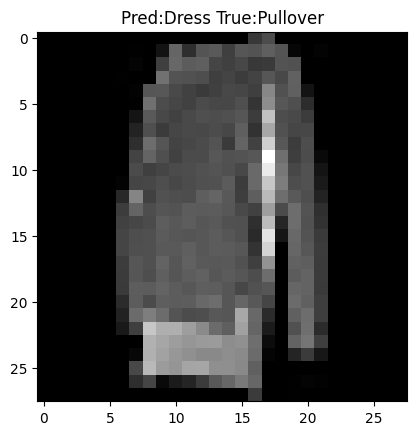

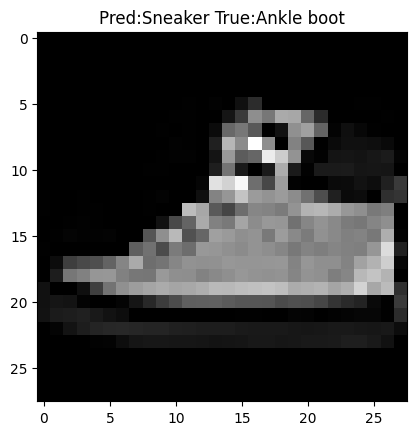

In [19]:
count = 0

for images,labels in test_loader:

    images_flat = images.view(images.size(0),-1).to(device)
    outputs = bn_model(images_flat)

    _,pred = torch.max(outputs,1)

    for i in range(len(pred)):
        if pred[i] != labels[i]:

            plt.imshow(images[i].squeeze(),cmap="gray")
            plt.title(f"Pred:{classes[pred[i]]} True:{classes[labels[i]]}")
            plt.show()

            count+=1
            if count==10:
                break
    if count==10:
        break

In [20]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [21]:
print("Model | Parameters | Accuracy | Time")

print("A",count_params(modelA),A_acc,A_time)
print("B",count_params(modelB),B_acc,B_time)
print("C",count_params(modelC),C_acc,C_time)
print("Small",count_params(small),test_accuracy(small))
print("Large",count_params(large),test_accuracy(large))
print("BatchNorm",count_params(bn_model),test_accuracy(bn_model),bn_time)

Model | Parameters | Accuracy | Time
A 25450 86.08 143.10017681121826
B 109386 87.47 153.66558933258057
C 242762 87.73 169.2964506149292
Small 3190 80.39
Large 1764426 88.18
BatchNorm 243658 88.31 174.3926486968994
